# 기초

## All Imports and readCSV

In [21]:
#.\.venv\Scripts\Activate.ps1

#기초
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Linear Regression & Classification
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Metric
from sklearn.metrics import accuracy_score, f1_score,classification_report

# Scaler
from sklearn.preprocessing import StandardScaler

# Grid Search CV
from sklearn.model_selection import GridSearchCV

#Korean
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

sleep = pd.read_csv("./dataset/Sleep_health_and_lifestyle_dataset.csv")
#sleep.head()

In [22]:
"""
ID가 한국어인 경우 필요함
import os
temp_path = "C:/temp"
if not os.path.exists(temp_path):
    os.makedirs(temp_path)

os.environ['JOBLIB_TEMP_FOLDER'] = temp_path
"""

'\nID가 한국어인 경우 필요함\nimport os\ntemp_path = "C:/temp"\nif not os.path.exists(temp_path):\n    os.makedirs(temp_path)\n\nos.environ[\'JOBLIB_TEMP_FOLDER\'] = temp_path\n'

## Data Cleanup

In [23]:
# 1. Male = 1, Female = 2
sleep['Gender'] = sleep['Gender'].map({'Male': 1, 'Female': 2})

# 2. Map BMI Category: Normal/Normal Weight = 1, Overweight = 2, Obese = 3
bmi_mapping = {
    'Normal': 1, 
    'Normal Weight': 1, 
    'Overweight': 2, 
    'Obese': 3
}
sleep['BMI Category'] = sleep['BMI Category'].map(bmi_mapping)

# 3. Map Sleep Disorder : No disorder = 0, Disorder = 1
sleep['Sleep Disorder'] = sleep['Sleep Disorder'].apply(lambda x: 0 if pd.isna(x) or x == 'None' else 1)

#4. Job
unique_jobs = sleep['Occupation'].dropna().unique()
job_mapping = {job: index + 1 for index, job in enumerate(unique_jobs)}
sleep['Occupation'] = sleep['Occupation'].map(job_mapping)


# 5. Blood Pressure (평균 동맥앞으로 변경)
sleep[['Systolic', 'Diastolic']] = sleep['Blood Pressure'].str.split('/', expand=True)
sleep['Systolic'] = sleep['Systolic'].astype(float)
sleep['Diastolic'] = sleep['Diastolic'].astype(float)
sleep['Mean_Arterial_Pressure'] = (sleep['Systolic'] + (2 * sleep['Diastolic'])) / 3
sleep['Systolic'] = sleep['Systolic'].astype(float)
sleep = sleep.drop(columns=['Blood Pressure','Diastolic','Systolic'])

# 6. 건강관련 자료를 합함
scaler = StandardScaler()
sleep[['Scaled_Activity', 'Scaled_Steps']] = scaler.fit_transform(sleep[['Physical Activity Level', 'Daily Steps']])
sleep['Overall_Activity_Score'] = (sleep['Scaled_Activity'] + sleep['Scaled_Steps']) / 2
sleep = sleep.drop(['Physical Activity Level', 'Daily Steps', 'Scaled_Activity', 'Scaled_Steps'], axis=1)

#  Occupation and Person ID columns
columns_to_drop = ['Occupation', 'Person ID']
sleep = sleep.drop(columns=columns_to_drop, errors='ignore')

#sleep.info()

# EDA (Explatory Data Analysis)

## Heatmap

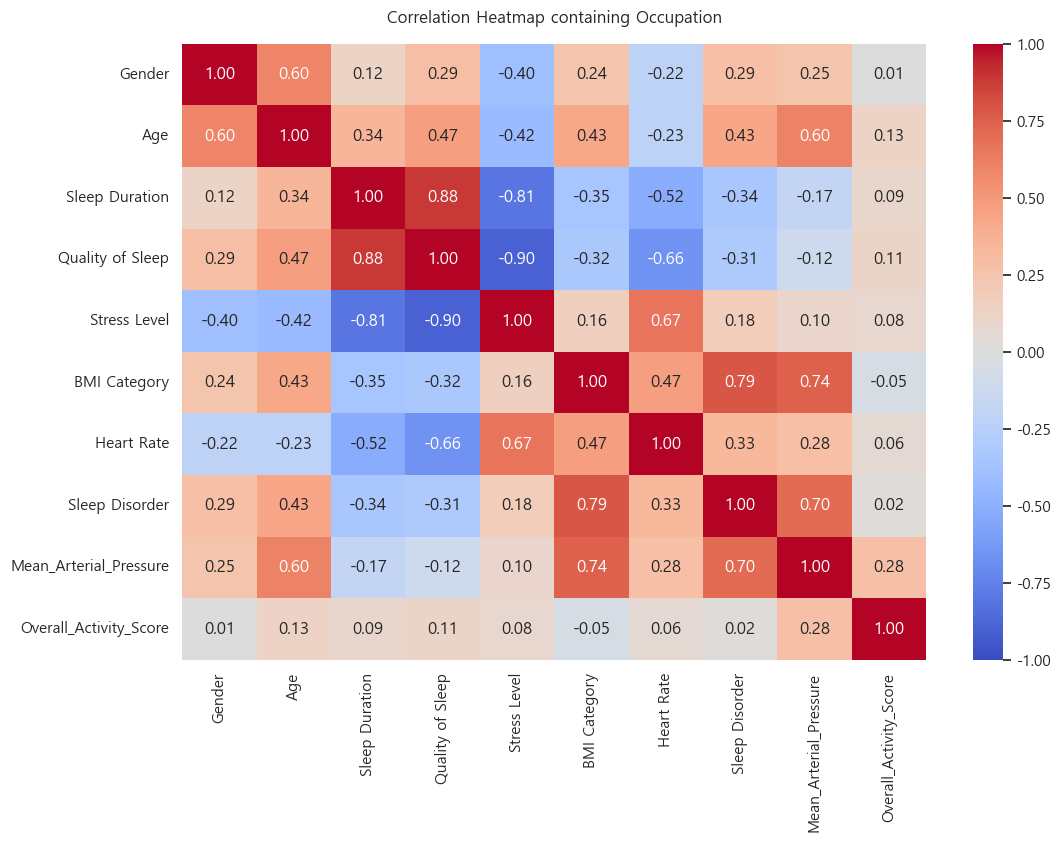

In [24]:
plt.figure(figsize=(12, 8)) 
corr = sleep.corr()
ax = sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap containing Occupation", pad=15)

plt.show()

## Scatter Plot

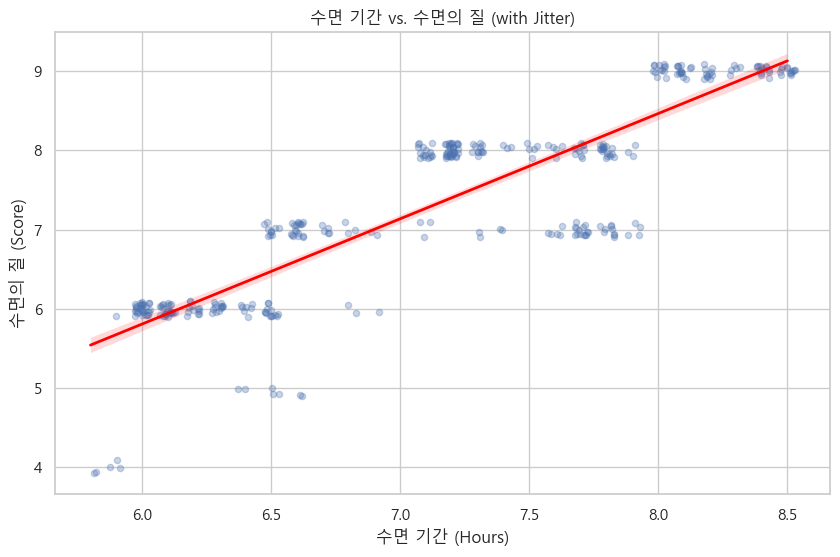

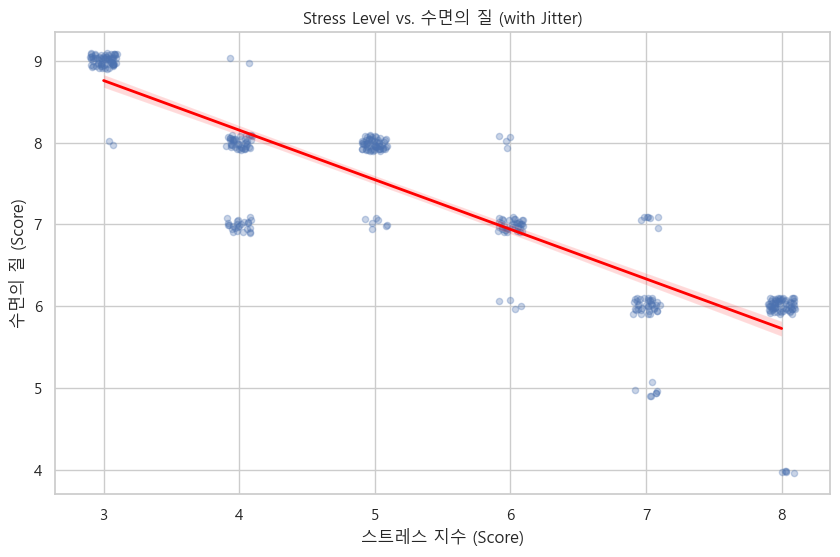

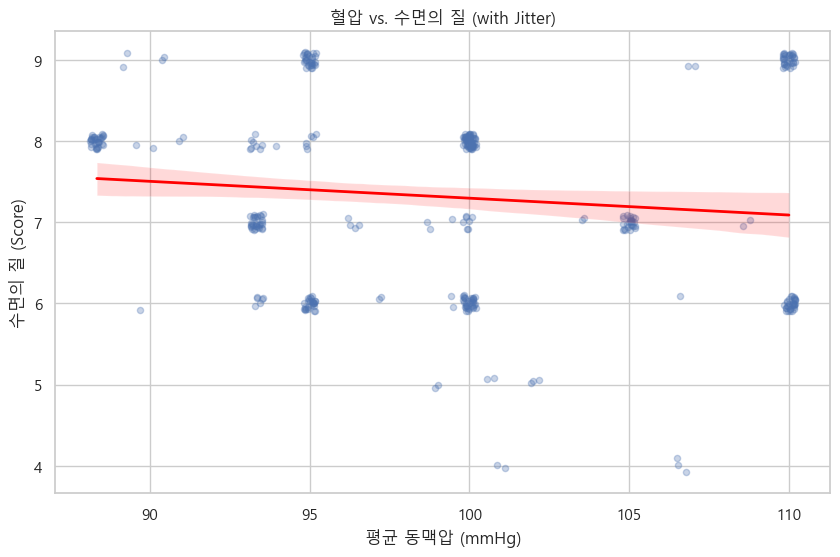

In [25]:
# --- 그래프 1: 수면 기간 vs 수면의 질 ---
plt.figure(figsize=(10, 6))
sns.regplot(data=sleep, x='Sleep Duration', y='Quality of Sleep',
            x_jitter=0.03, y_jitter=0.1,  # 미세한 지터 추가
            scatter_kws={'alpha':0.3, 's':20}, 
            line_kws={'color':'red', 'lw':2})
plt.title('수면 기간 vs. 수면의 질 (with Jitter)')
plt.xlabel('수면 기간 (Hours)')
plt.ylabel('수면의 질 (Score)')
plt.show()

# --- 그래프 2: 스트레스 지수 vs 수면의 질 ---
plt.figure(figsize=(10, 6))
sns.regplot(data=sleep, x='Stress Level', y='Quality of Sleep',
            x_jitter=0.1, y_jitter=0.1,   # 이산형 데이터이므로 지터를 조금 더 줌
            scatter_kws={'alpha':0.3, 's':20}, 
            line_kws={'color':'red', 'lw':2})
plt.title('Stress Level vs. 수면의 질 (with Jitter)')
plt.xlabel('스트레스 지수 (Score)')
plt.ylabel('수면의 질 (Score)')
plt.show()

# --- 그래프 3: 평균 동맥압(MAP) vs 수면의 질 ---
plt.figure(figsize=(10, 6))
sns.regplot(data=sleep, x='Mean_Arterial_Pressure', y='Quality of Sleep',
            x_jitter=0.2, y_jitter=0.1,   # 연속형이지만 밀집된 구간 해소
            scatter_kws={'alpha':0.3, 's':20}, 
            line_kws={'color':'red', 'lw':2})
plt.title('혈압 vs. 수면의 질 (with Jitter)')
plt.xlabel('평균 동맥압 (mmHg)')
plt.ylabel('수면의 질 (Score)')
plt.show()

## Histogram

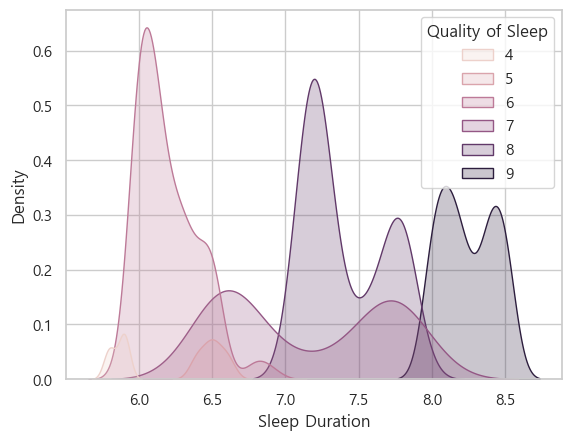

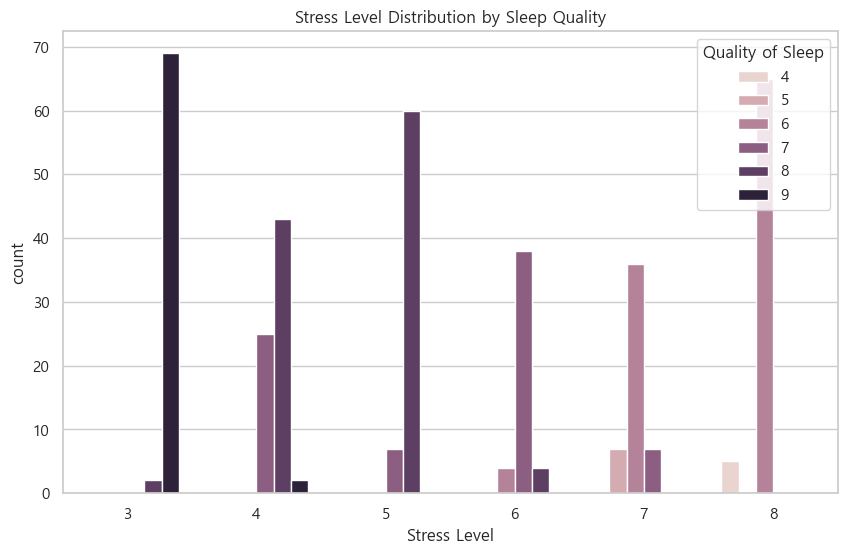

<Axes: xlabel='Stress Level', ylabel='Count'>

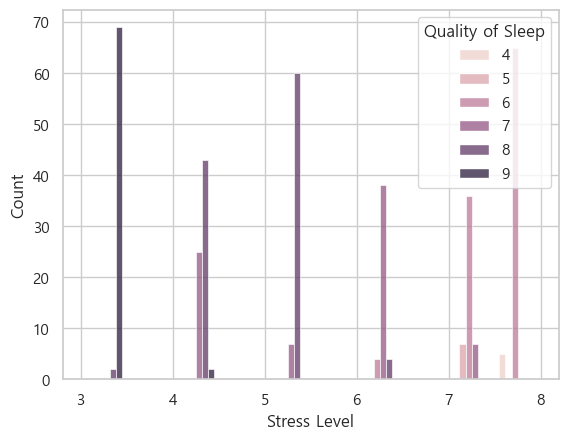

In [26]:
sns.kdeplot(data=sleep, x='Sleep Duration', hue='Quality of Sleep', fill=True)
plt.figure(figsize=(10, 6))
sns.countplot(data=sleep, x='Stress Level', hue='Quality of Sleep')
plt.title('Stress Level Distribution by Sleep Quality')
plt.show()

sns.histplot(data=sleep, x='Stress Level', hue='Quality of Sleep', 
             multiple="dodge", shrink=.8)

C:\Users\human-23\AppData\Local\Temp\ipykernel_6896\507240399.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=sleep, x='Quality of Sleep', palette='viridis')


<Figure size 640x480 with 0 Axes>

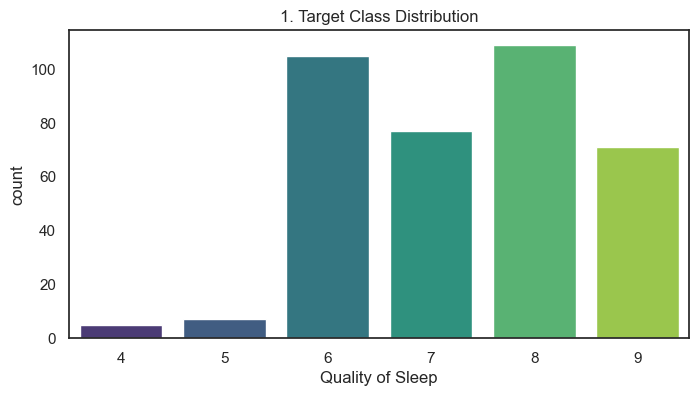

C:\Users\human-23\AppData\Local\Temp\ipykernel_6896\507240399.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=sleep, x='Quality of Sleep', y='Sleep Duration', palette='muted')


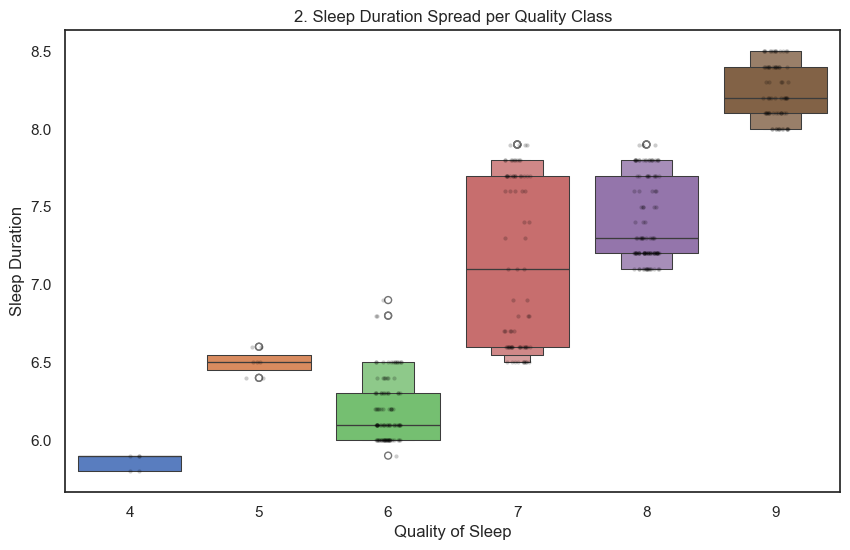

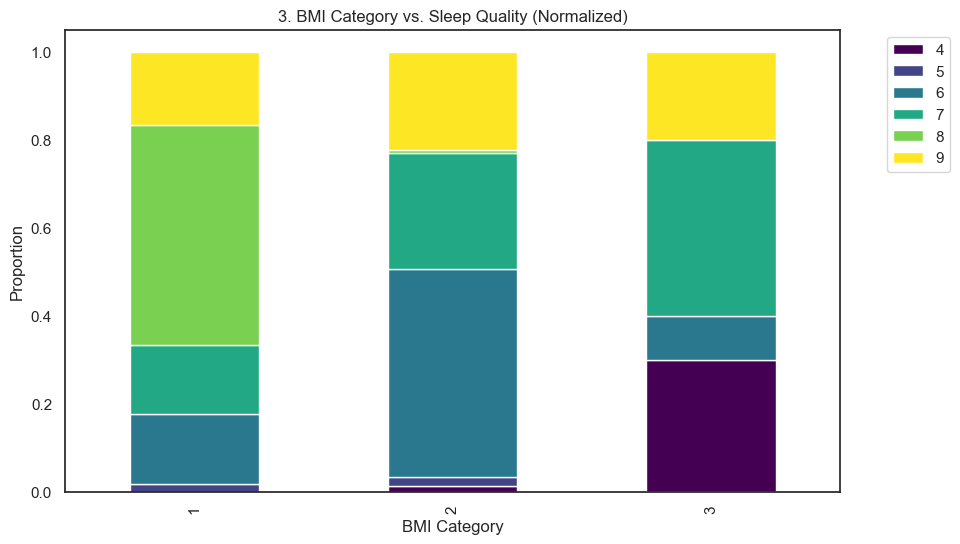

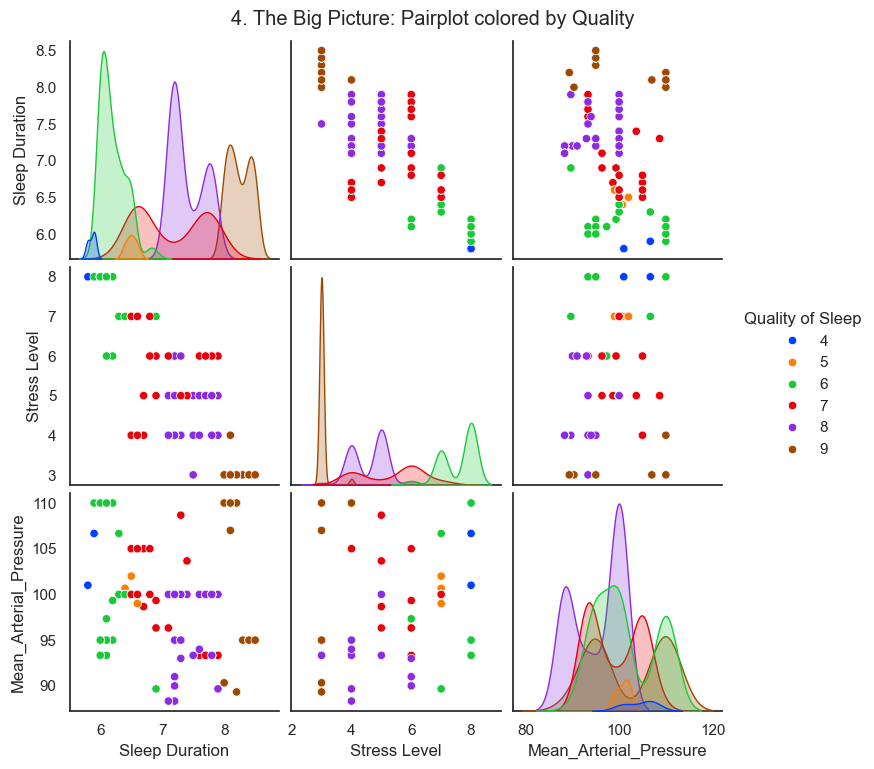

In [27]:
# 스타일 설정 (이거 하나면 충분하네)
sns.set_theme(style="white")
plt.tight_layout()

# 1. Target Distribution (클래스 불균형 확인)
# 여기서 특정 점수의 막대가 너무 낮다면, 모델이 그 점수를 학습할 때 "샘플 부족"을 겪을 거라는 걸 미리 인지하게.
"""
시니어의 진단: "심각한 클래스 불균형(Class Imbalance) 경보"

비판: 4점과 5점 데이터 보이나? 8점과 9점에 비해 턱없이 부족하네.

Insight: 모델을 학습시키면 8점과 9점은 기가 막히게 맞추겠지만, 4점과 5점은 아예 무시할 가능성이 높네. 나중에 모델 평가할 때 'Accuracy'만 보면 안 되고, Confusion Matrix를 반드시 확인해야 하네. 4점을 4점이라고 부르지 못하는 '홍길동 모델'이 될 수도 있어.
"""
plt.figure(figsize=(8, 4))
sns.countplot(data=sleep, x='Quality of Sleep', palette='viridis')
plt.title('1. Target Class Distribution')
plt.show()

# 2. Feature Separability (박스보다 정밀한 분포 확인)
plt.figure(figsize=(10, 6))
# Boxenplot은 박스플롯보다 데이터 밀도를 더 세밀하게 보여주지.
# 박스들 사이에 층이 지는가? 층이 명확할수록 그 피처는 분류 모델에서 '치트키'가 된다네.
"""
시니어의 진단: "데이터의 경직성 확인"

비판: 4점과 5점의 박스가 왜 그냥 선(Line)으로 보일까? 그건 그 그룹의 사람들이 전부 똑같은 시간을 잤다고 대답했기 때문이네(분산 0).

Insight: 수면 시간이 8시간을 넘어가면 9점이 될 확률이 급격히 높아지는 게 보이지? 박스들이 계단식으로 예쁘게 층이 나뉘어 있는 걸 보니, 이 변수는 분류 모델의 최고의 무기가 될 걸세.
"""
sns.boxenplot(data=sleep, x='Quality of Sleep', y='Sleep Duration', palette='muted')
sns.stripplot(data=sleep, x='Quality of Sleep', y='Sleep Duration', color='black', alpha=0.2, size=3)
plt.title('2. Sleep Duration Spread per Quality Class')
plt.show()

# 3. Categorical Impact (범주형 변수의 영향력 비중)
# crosstab과 plot(kind='bar', stacked=True) 조합이 가장 깔끔하네.
# BMI 범주별로 색깔 비중이 다른가? 만약 'Normal'과 'Overweight'의 색깔 구성이 비슷하다면 BMI는 분류에 큰 도움이 안 되는 걸세.
"""
시니어의 진단: "가장 강력한 분류 힌트 발견"

비판: 범례(Legend)가 그래프를 가리고 있군. bbox_to_anchor 좌표 수정을 좀 하게.

Insight: 보게나. 'Obese(비만)' 그룹은 대부분 4, 5점에 몰려있고, 'Normal' 그룹은 8, 9점에 몰려있지. 이건 BMI만 봐도 수면의 질을 어느 정도 맞출 수 있다는 뜻이네. 분류 모델이 '결정 트리'를 만들 때 BMI를 상단 노드에 배치할 아주 강력한 근거가 되네.
"""
bmi_sleep = pd.crosstab(sleep['BMI Category'], sleep['Quality of Sleep'], normalize='index')
bmi_sleep.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis', edgecolor='white')
plt.title('3. BMI Category vs. Sleep Quality (Normalized)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylabel('Proportion')
plt.show()

# 4. Multivariate Analysis (변수 간의 '색깔' 분리도 확인)
# : 점들이 색깔별로 뭉쳐(Cluster) 있는가? 뭉쳐 있다면 분류 모델은 아주 정확하게 작동할 거야. 만약 다 섞여 있다면 다른 피처를 더 찾아야 하네.
# 모든 변수를 다 그리면 느려지니 핵심 3개만 골랐네.
"""
시니어의 진단: "회귀(Regression) 포기의 결정적 증거"

비판: 대각선의 KDE 산들을 보게. 아주 뾰족뾰족한 바늘 같지? 데이터가 연속적이지 않고 정수형으로 딱딱 끊어진다는 증거네.

Insight: 변수들끼리 만나는 지점에 색깔(점)들이 뭉쳐있는 게 보이나? 특히 Stress Level과 Quality가 만나는 곳을 보게. 색깔들이 거의 섞이지 않고 자기들끼리 구역을 나누고 있지? 이건 선형 회귀보다 Random Forest Classifier가 압승할 수밖에 없는 구조라는 걸 증명하네.
"""
sns.pairplot(sleep[['Quality of Sleep', 'Sleep Duration', 'Stress Level', 'Mean_Arterial_Pressure']], 
             hue='Quality of Sleep', palette='bright', diag_kind='kde')
plt.suptitle('4. The Big Picture: Pairplot colored by Quality', y=1.02)
plt.show()

### 데이터 시각화 결과, 클래스 불균형이 존재하며 변수 간 분리도가 명확하여 RandomForestClassifier가 적합함

# Training

## Baseline

In [28]:
# 1. 데이터 분리 (X: 특징, y: 목표값)
# 여기서 'Quality of Sleep'을 제외한 나머지 컬럼들을 X로 설정하세요.
X = sleep.drop('Quality of Sleep', axis=1)
y = sleep['Quality of Sleep']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [31]:
# 모델 리스트 업데이트
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced'),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = [] 

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # 지표 계산
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    
    # 결과 저장
    results.append({"Model": name, "Accuracy": acc, "F1_Macro": f1})
    
    print(f"\n" + "="*50)
    print(f" MODEL: {name}")
    print("="*50)
    print(classification_report(y_test, y_pred, zero_division=0))

# 나중에 한눈에 보기 위해
results_df = pd.DataFrame(results).sort_values(by='F1_Macro', ascending=False)
print("\n--- Final Comparison ---")
print(results_df)


 MODEL: Logistic Regression
              precision    recall  f1-score   support

           4       1.00      1.00      1.00         1
           5       0.50      1.00      0.67         1
           6       1.00      1.00      1.00        21
           7       1.00      0.88      0.93        16
           8       0.96      1.00      0.98        22
           9       1.00      1.00      1.00        14

    accuracy                           0.97        75
   macro avg       0.91      0.98      0.93        75
weighted avg       0.98      0.97      0.97        75


 MODEL: Decision Tree
              precision    recall  f1-score   support

           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       1.00      1.00      1.00        21
           7       1.00      1.00      1.00        16
           8       1.00      1.00      1.00        22
           9       1.00      1.00      1.00        14

    accuracy             

## Confirming Data Leak

--- [Random Forest] Feature Importances ---
1. Sleep Duration            : 0.2585
2. Stress Level              : 0.2145
3. Overall_Activity_Score    : 0.1469
4. Age                       : 0.1421
5. Heart Rate                : 0.1392
6. Mean_Arterial_Pressure    : 0.0420
7. BMI Category              : 0.0345
8. Sleep Disorder            : 0.0122
9. Gender                    : 0.0100


C:\Users\human-23\AppData\Local\Temp\ipykernel_6896\4224757868.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=feature_names[indices], palette='magma')


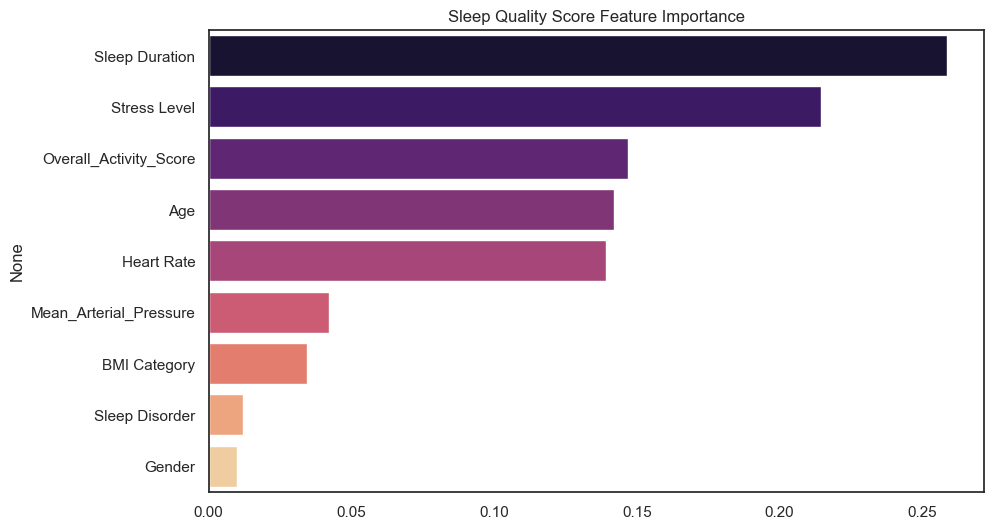

In [ ]:
#only Random Forest to check for dataleak
rf_model = models["Random Forest"]

# 2. 피처 중요도 추출
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

print("--- [Random Forest] Feature Importances ---")
for f in range(X.shape[1]):
    print(f"{f + 1}. {feature_names[indices[f]]:<25} : {importances[indices[f]]:.4f}")

# 3. 시각화
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='magma')
plt.title('Sleep Quality Score Feature Importance')
plt.xlabel('Feature', fontsize=12)
plt.ylabel('Feature Importance', fontsize=12)
plt.show()

## Erasing Stress Level and Sleep Duration

In [33]:
# 1. 너무 강력한 힌트들을 제거한 새로운 X 생성
X_hard_mode = X.drop(['Sleep Duration', 'Stress Level'], axis=1)

# 2. 데이터 다시 나누기
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_hard_mode, y, test_size=0.2, random_state=42, stratify=y
)

# 3. 스케일링 다시 하기
scaler_h = StandardScaler()
X_train_h_scaled = scaler_h.fit_transform(X_train_h)
X_test_h_scaled = scaler_h.transform(X_test_h)

# 4. 랜덤 포레스트로만 다시 훈련해보기
rf_hard = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_hard.fit(X_train_h_scaled, y_train_h)
y_pred_h = rf_hard.predict(X_test_h_scaled)

print("--- [Hard Mode] Performance without Top 2 Features ---")
print(classification_report(y_test_h, y_pred_h, zero_division=0))

--- [Hard Mode] Performance without Top 2 Features ---
              precision    recall  f1-score   support

           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       0.86      0.90      0.88        21
           7       0.76      0.81      0.79        16
           8       1.00      0.91      0.95        22
           9       1.00      1.00      1.00        14

    accuracy                           0.91        75
   macro avg       0.94      0.94      0.94        75
weighted avg       0.91      0.91      0.91        75



In [34]:
# 하드 모드용 결과 저장
hard_results = []

print(f"{'Model (Hard Mode)':<20} | {'Accuracy':<10} | {'F1 Macro':<10}")
print("-" * 50)

for name, model in models.items():
    # 하드 모드 데이터(X_train_h_scaled)로 학습
    model.fit(X_train_h_scaled, y_train_h)
    y_pred = model.predict(X_test_h_scaled)
    
    acc = accuracy_score(y_test_h, y_pred)
    f1 = f1_score(y_test_h, y_pred, average='macro')
    
    hard_results.append({"Model": name, "Accuracy": acc, "F1_Macro": f1})
    print(f"{name:<20} | {acc:<10.4f} | {f1:<10.4f}")

# 결과 비교 데이터프레임
hard_results_df = pd.DataFrame(hard_results).sort_values(by='F1_Macro', ascending=False)

Model (Hard Mode)    | Accuracy   | F1 Macro  
--------------------------------------------------
Logistic Regression  | 0.8933     | 0.8700    
Decision Tree        | 0.9067     | 0.8879    
Random Forest        | 0.9067     | 0.9373    
SVM                  | 0.8800     | 0.8655    
KNN                  | 0.8533     | 0.5853    


## GridSearchCV

In [35]:
# 1. 탐색할 파라미터 그리드 설정
param_grid = {
    'n_estimators': [100, 200, 300], # 나무의 개수
    'max_depth': [None, 10, 20, 30], # 나무의 깊이 (오버피팅 방지)
    'min_samples_split': [2, 5, 10],  # 노드를 나누기 위한 최소 샘플 수
    'min_samples_leaf': [1, 2, 4],    # 리프 노드에 있어야 할 최소 샘플 수
    'class_weight': ['balanced', 'balanced_subsample'] # 불균형 해소 전략
}

# 2. GridSearchCV 객체 생성
# cv=5: 5-Fold Cross Validation (데이터를 5등분해서 검증)
# scoring='f1_macro': 우리의 핵심 지표인 F1 Macro를 기준으로 최적화
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1, # 모든 CPU 코어 사용 (빠름!)
    verbose=1
)

# 3. 최적의 조합 찾기 (Hard Mode 데이터 사용)
grid_search.fit(X_train_h_scaled, y_train_h)

# 4. 결과 확인
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best F1 Macro Score: {grid_search.best_score_:.4f}")

# 5. 최적의 모델로 최종 테스트 데이터 평가
best_rf = grid_search.best_estimator_
final_pred = best_rf.predict(X_test_h_scaled)

print("\n--- Final Tuned Model Report ---")
print(classification_report(y_test_h, final_pred, zero_division=0))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


c:\Workspace\Test\.venv\lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best F1 Macro Score: 0.8864

--- Final Tuned Model Report ---
              precision    recall  f1-score   support

           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         1
           6       0.86      0.90      0.88        21
           7       0.76      0.81      0.79        16
           8       1.00      0.91      0.95        22
           9       1.00      1.00      1.00        14

    accuracy                           0.91        75
   macro avg       0.94      0.94      0.94        75
weighted avg       0.91      0.91      0.91        75



## Best model

C:\Users\human-23\AppData\Local\Temp\ipykernel_6896\3295160809.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


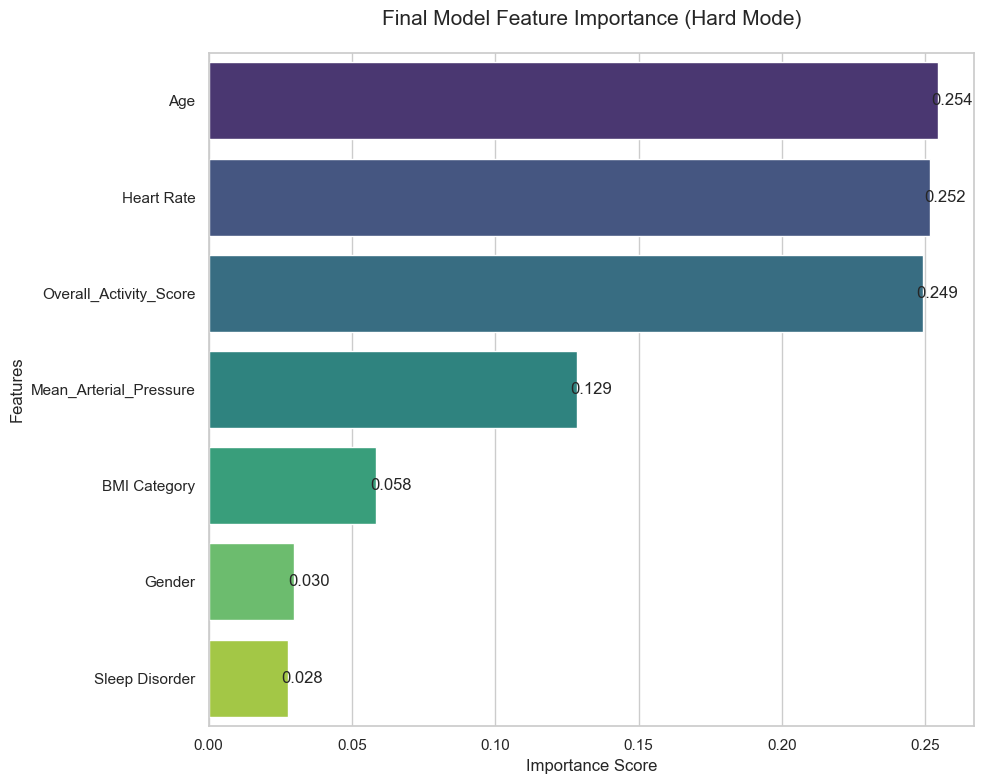

In [36]:
# 1. 최적의 모델에서 피처 중요도 추출
importances = best_rf.feature_importances_
# 'Hard Mode'에서 사용했던 컬럼명들 (X_hard_mode.columns)
feature_names = X_hard_mode.columns

# 2. 데이터프레임으로 변환 후 정렬
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. 시각화 (발표용으로 깔끔하게!)
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

# 막대 그래프 그리기
plot = sns.barplot(
    data=feature_importance_df, 
    x='Importance', 
    y='Feature', 
    palette='viridis'
)

# 그래프 위에 수치 표시 (디테일이 생명이네!)
for p in plot.patches:
    width = p.get_width()
    plt.text(width + 0.005, p.get_y() + p.get_height()/2, 
             f'{width:.3f}', ha='center', va='center')

plt.title('Final Model Feature Importance (Hard Mode)', fontsize=15, pad=20)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

### Confirming  multicollinearity 

--- Correlation Matrix ---
                        Heart Rate  Overall_Activity_Score
Heart Rate                1.000000                0.056647
Overall_Activity_Score    0.056647                1.000000


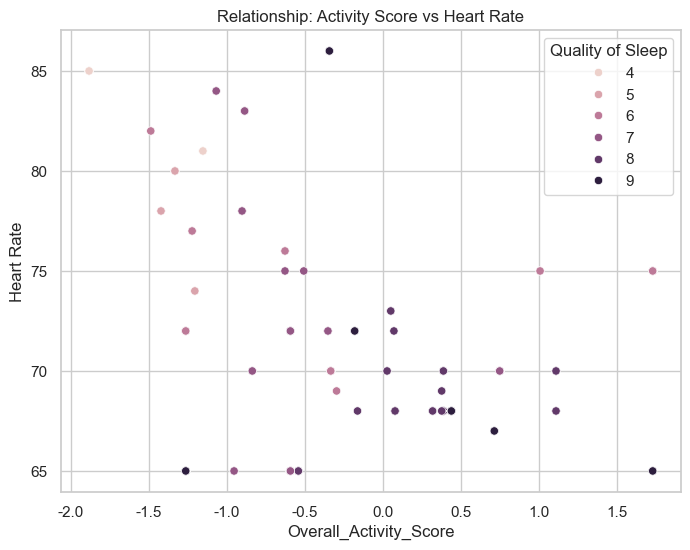

In [37]:
# 두 변수 간의 상관계수 확인
correlation = sleep[['Heart Rate', 'Overall_Activity_Score']].corr()
print("--- Correlation Matrix ---")
print(correlation)

# 시각화로 확인 (산점도)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=sleep, x='Overall_Activity_Score', y='Heart Rate', hue='Quality of Sleep')
plt.title('Relationship: Activity Score vs Heart Rate')
plt.show()

## WHERE IS CONFUSION_MATRIX

# Dumping PKL

In [ ]:
import joblib

# 1. 튜닝이 완료된 최종 챔피언 모델 저장
joblib.dump(best_rf, './models/sleep_model.pkl')

# 2. 하드모드에서 사용했던 스케일러 저장 (이게 없으면 새로운 입력값을 스케일링 못함!)
joblib.dump(scaler_h, './models/sleep_scaler.pkl')

['sleep_scaler.pkl']